# TPC-C Collector Demo

# Missing
* connection data beyond loading
* join to connection data
* join to monitoring_single
* connection and configuration also in monitoring and connection df

## Naming
* There is an experiment having a code, say `1775855486`.
* The experiment inspects a SUT, say `PostgreSQL-A`. This is called a `configuration`.
* The experiment is run several times, say twice. The indicator of the run is called `experiment_run`.
* Each run can have several phases as a sequence. The number of the phase is called `client`. The state of the configuration in a phase is called a `connection`.
* Each client can have several `pods`, that are run in parallel. A pod represents a driver.
* Performance metrics are collected per driver pod.  
    The naming of an instance is `<sut>-<experiment_run>-<client>-<pod>`. It is unique per experiment.
* Monitoring metrics are collected per phase. They are automatically aggregated across parallel pods.  
    The naming of an instance is `<sut>-<experiment_run>-<client>`. It is unique per experiment.

## Aggregation
* Aggregation is complicated. Some metrics are aggregated via count, sum, max or average. Others cannot be aggregated sensibly, like experiment code or latency percentiles.
* There are helper functions to aggregated pods that are certainly run in parallel.  
  So `<sut>-<experiment_run>-<client>-<pod>` are aggregated to `<sut>-<experiment_run>-<client>`.
* An exception is multi-tenancy.

## Class `collector`
* constructor `collectors.benchbase(path, codes)`
* evaluator object `evaluate = collect.get_evaluator()`
* dataframe of connection infos `collect.get_connections()`
  * index is name of client
* **monitoring metrics**
  * dataframe of available metrics `collect.df_metrics`
    * index is key of metric
  * dataframe of monitored components `collect.get_monitored_phases()`
    * index is key of component
  * dataframe of aggregated metrics per connection `collect.get_monitoring_single_all()`
    * index is name of client
    * metrics aggregated per code, experiment_run and client
  * dataframe of aggregated metrics per connection and across tenants `collect.get_monitoring_all()`
    * index just enumerates
    * metrics aggregated per code, experiment_run and client and across tenants
  * dataframe of time series for a metric of a connection in an experiment `collect.get_monitoring_timeseries_single(code, metric)`
    * index is name of connection
    * unstacked (wide format)
  * dataframe of time series for a metric in all experiments `collect.get_monitoring_timeseries_all(metric)`
    * index just enumerates
    * stacked (long format)
* **performance metrics**
  * dataframe of loading metrics `collect.get_loading_time_max_all()`
    * index is name of client
  * dataframe of performance aggregated per parallel client `collect.get_performance_all()`
    * index just enumerates
    * performance aggregated per code, experiment_run and client
  * dataframe of performance for one experiment `collect.get_performance_single()`
    * performance of each single client (driver)
    * index is name of client pod
  * dataframe of performance for all experiments `collect.get_performance_all_single()`
    * performance of each single client (driver)
    * index is name of client pod


[1] [Benchmarking Multi-Tenant Architectures in PostgreSQL](https://doi.org/10.48786/edbt.2026.46)
> Erdelt, P.K., and Rabl T. (2026)
> In: Proceedings 29th International Conference on Extending Database Technology, EDBT 2026
> OpenProceedings.org
> https://doi.org/10.48786/edbt.2026.46


In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.float_format = '{:.2f}'.format

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
from notebookutils import *

# Collect Results

In [3]:
path = r"D:\data\benchmarks"
#path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [4]:
codes = [
    "1776068373",
    "1776070965"
]

codes
codes = [
    "1775852722",
    "1775855486"
]
codes

['1775852722', '1775855486']

In [5]:
collect = collectors.benchbase(path, codes)

# Get all Metrics Metadata

## Metrics Names and Types

Metrics that are derived from monitoring

In [6]:
collect.df_metrics

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


## Names of Monitored Components

Names of components and their phases

In [7]:
collect.get_monitored_components()

,description
loading,Loading phase: SUT deployment
loader,Loading phase: component loader
stream,Execution phase: SUT deployment
benchmarker,Execution phase: component benchmarker


# Get Connection Infos

List of states of SUTs, containing loading infos.

In [8]:
df=collect.get_connections()

In [9]:
df.T

,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486
connection,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
configuration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
experiment_run,1,1,1,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2
client,1,2,2,1,2,2,1,1,1,1,2,2,2,2,2,2,2,2,1,1,1,1,2,2,2,2,2,2,2,2
dockerimage,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18

In [10]:
df[['phase', 'code', 'connection', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']]

,phase,code,connection,configuration,experiment_run,client,type_tenants,num_tenants,vol_tenants
1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-1,1775852722,1775852722-PostgreSQL-1-1-1024-1-1-1,,1,1,,0,False
1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722,1775852722-PostgreSQL-1-1-1024-1-2-1,,1,2,,0,False
1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722,1775852722-PostgreSQL-1-1-1024-1-2-2,,1,2,,0,False
1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-1,1775852722,1775852722-PostgreSQL-1-1-1024-2-1-1,,2,1,,0,False
1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722,1775852722-PostgreSQL-1-1-1024-2-2-1,,2,2,,0,False
1775852722-PostgreSQL-1-1-1024-2-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775852722,1775852722-PostgreSQL-1-1-1024-2-2-2,,2,2,,0,False
1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024-1-1-1,,1,1,,0,False
1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024-1-1-2,,1,1,,0,False
1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024-1-1-3,,1,1,,0,False
1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024-1-1-4,,1,1,,0,False


In [11]:
collectors.get_non_constant(df).T

,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486
connection,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
experiment_run,1,1,1,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2
client,1,2,2,1,2,2,1,1,1,1,2,2,2,2,2,2,2,2,1,1,1,1,2,2,2,2,2,2,2,2
time_load,601.00,601.00,601.00,665.00,665.00,665.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,608.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00,668.00
time_ingest,245

# Monitoring Aggregated per Phase

In [12]:
df = collect.get_monitoring_aggregated_per_phase("stream")
df.T

,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],9193.61,9872.40,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],2578.09,2557.14,2639.50,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54
Network Rx Total [MiB],3965.11,2230.61,3955.69,1651.63,3756.65,1799.33,3557.06,1781.43
Network Tx Total [MiB],2948.03,1934.05,3395.20,1732.26,3170.12,2044.35,2602.92,1740.33


### With Metadata

In [13]:
df = collect.add_metadata(df)
df.T

combine on index and column 'phase'


phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],9193.61,9872.40,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],2578.09,2557.14,2639.50,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54
Network Rx Total [MiB],3965.11,2230.61,3955.69,1651.63,3756.65,1799.33,3557.06,1781.43
Network Tx Total [MiB],2948.03,1934.05,3395.20,1732.26,3170.12,2044.35,2602.92,1740.33


In [14]:
df[['phase', 'code', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']].T

phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
code,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486
configuration,,,,,,,,
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
type_tenants,,,,,,,,
num_tenants,0,0,0,0,0,0,0,0
vol_tenants,False,False,False,False,False,False,False,False


# Time Series of a Single Metric for a Single Experiment

In [15]:
metric = 'total_cpu_memory'
code = codes[0]
df = collect.get_monitoring_timeseries_per_phase(code, metric=metric, component='stream')
df.T

,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2
0,7576.82,8234.52,7575.90,8237.32
1,7576.82,8234.52,7575.90,8237.32
2,7576.82,8234.52,7575.90,8237.32
3,7576.82,8234.52,7575.90,8237.32
4,7576.82,8234.52,7575.90,8237.32
5,7576.82,8234.52,7575.90,8237.32
6,7576.82,9163.68,7575.90,8237.32
7,7576.82,9163.68,7575.90,8237.32
8,7576.82,9163.68,7575.90,8237.32
9,7576.82,9163.68,7575.90,8237.32


### With Metadata

In [16]:
df = collect.add_metadata(df)
df.T

combine on index and column 'phase'


phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2
0,7576.82,8234.52,7575.90,8237.32
1,7576.82,8234.52,7575.90,8237.32
2,7576.82,8234.52,7575.90,8237.32
3,7576.82,8234.52,7575.90,8237.32
4,7576.82,8234.52,7575.90,8237.32
5,7576.82,8234.52,7575.90,8237.32
6,7576.82,9163.68,7575.90,8237.32
7,7576.82,9163.68,7575.90,8237.32
8,7576.82,9163.68,7575.90,8237.32
9,7576.82,9163.68,7575.90,8237.32


In [17]:
df[['phase', 'code', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']].head()

,phase,code,configuration,experiment_run,client,type_tenants,num_tenants,vol_tenants
phase,,,,,,,,
1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-1,1775852722,,1,1,,0,False
1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722,,1,2,,0,False
1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-1,1775852722,,2,1,,0,False
1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775852722,,2,2,,0,False


# Time Series of a Single Metric for All Experiments

In [18]:
metric = 'total_cpu_memory'
code = codes[0]
df = collect.get_monitoring_timeseries_all(metric=metric)
df.head()

,timestamp,code,phase,experiment_run,client,type_tenants,vol_tenants,num_tenants,metric,component,value
0,0,1775852722,1775852722-PostgreSQL-1-1-1024-1-1,1,1,,False,0,total_cpu_memory,stream,7576.82
1,0,1775852722,1775852722-PostgreSQL-1-1-1024-1-2,1,2,,False,0,total_cpu_memory,stream,16469.04
2,0,1775852722,1775852722-PostgreSQL-1-1-1024-2-1,2,1,,False,0,total_cpu_memory,stream,7575.90
3,0,1775852722,1775852722-PostgreSQL-1-1-1024-2-2,2,2,,False,0,total_cpu_memory,stream,16474.65
4,0,1775855486,1775855486-PostgreSQL-1-1-1024-1-1,1,1,,False,0,total_cpu_memory,stream,30363.56


In [19]:
df[['timestamp', 'phase', 'value']].head(8)

,timestamp,phase,value
0,0,1775852722-PostgreSQL-1-1-1024-1-1,7576.82
1,0,1775852722-PostgreSQL-1-1-1024-1-2,16469.04
2,0,1775852722-PostgreSQL-1-1-1024-2-1,7575.90
3,0,1775852722-PostgreSQL-1-1-1024-2-2,16474.65
4,0,1775855486-PostgreSQL-1-1-1024-1-1,30363.56
5,0,1775855486-PostgreSQL-1-1-1024-1-2,65955.81
6,0,1775855486-PostgreSQL-1-1-1024-2-1,30304.52
7,0,1775855486-PostgreSQL-1-1-1024-2-2,65869.56


In [20]:
df=collect.add_metadata(df)
df = df.sort_values(['timestamp', 'phase'])
df[['timestamp', 'phase', 'value']].head(8)

combine on columns phase


,timestamp,phase,value
1775852722-PostgreSQL-1-1-1024-1-1,0,1775852722-PostgreSQL-1-1-1024-1-1,7576.82
1775852722-PostgreSQL-1-1-1024-1-2,0,1775852722-PostgreSQL-1-1-1024-1-2,16469.04
1775852722-PostgreSQL-1-1-1024-2-1,0,1775852722-PostgreSQL-1-1-1024-2-1,7575.90
1775852722-PostgreSQL-1-1-1024-2-2,0,1775852722-PostgreSQL-1-1-1024-2-2,16474.65
1775855486-PostgreSQL-1-1-1024-1-1,0,1775855486-PostgreSQL-1-1-1024-1-1,30363.56
1775855486-PostgreSQL-1-1-1024-1-2,0,1775855486-PostgreSQL-1-1-1024-1-2,65955.81
1775855486-PostgreSQL-1-1-1024-2-1,0,1775855486-PostgreSQL-1-1-1024-2-1,30304.52
1775855486-PostgreSQL-1-1-1024-2-2,0,1775855486-PostgreSQL-1-1-1024-2-2,65869.56


In [21]:
df[['phase', 'code', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']].head()

,phase,code,configuration,experiment_run,client,type_tenants,num_tenants,vol_tenants
1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-1,1775852722,,1,1,,0,False
1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722,,1,2,,0,False
1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-1,1775852722,,2,1,,0,False
1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775852722,,2,2,,0,False
1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,,1,1,,0,False


## Custom Aggregation and Scale

In [22]:
metric = 'total_cpu_util'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["code", "experiment_run", "client", "type_tenants", "num_tenants"])["value"]
      .max()
      .reset_index()
)
#plot_bars(df_agg, y='value', title='Max CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)
df_agg.index.name = 'Max ' + collect.df_metrics.loc[metric]['title']
df_agg

,code,experiment_run,client,type_tenants,num_tenants,value
Max CPU Utilization,,,,,,
0,1775852722,1,1,,0,9.45
1,1775852722,1,2,,0,17.77
2,1775852722,2,1,,0,9.21
3,1775852722,2,2,,0,17.62
4,1775855486,1,1,,0,35.73
5,1775855486,1,2,,0,68.45
6,1775855486,2,1,,0,33.74
7,1775855486,2,2,,0,67.38


# Performance Results per Connection

In [23]:
df_performance = collect.get_performance_per_connection()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

connection_pod,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
connection,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,

### Add Metadata

In [24]:
df = collect.add_metadata(df_performance)
df.T

combine on index


connection_pod,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
connection,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,

# Performance Results per Total

In [25]:
df_performance = collect.get_performance_aggregated_per_phase()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)

In [26]:
df_performance.T

,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
code,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486
pod_count,1,2,1,2,4,8,4,8
duration,307,304,305,304,305,308,305,307
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,16384,16384,16384,20480,20480,20480,20480


### With Metadata

In [27]:
df = collect.add_metadata(df_performance)
df.T

combine on index and column 'phase'


phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
code,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486
pod_count,1,2,1,2,4,8,4,8
duration,307,304,305,304,305,308,305,307
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,16384,16384,16384,20480,20480,20480,20480
time,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00


In [28]:
df[['phase', 'code', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']]

,phase,code,configuration,experiment_run,client,type_tenants,num_tenants,vol_tenants
phase,,,,,,,,
1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-1,1775852722,1775852722-PostgreSQL-1-1-1024,1,1,,0,False
1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722,1775852722-PostgreSQL-1-1-1024,1,2,,0,False
1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-1,1775852722,1775852722-PostgreSQL-1-1-1024,2,1,,0,False
1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775852722,1775852722-PostgreSQL-1-1-1024,2,2,,0,False
1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024,1,1,,0,False
1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486,1775855486-PostgreSQL-1-1-1024,1,2,,0,False
1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486,1775855486-PostgreSQL-1-1-1024,2,1,,0,False
1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486,1775855486-PostgreSQL-1-1-1024,2,2,,0,False


In [29]:
collectors.get_non_constant(df).T

phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
code,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486
pod_count,1,2,1,2,4,8,4,8
duration,307,304,305,304,305,308,305,307
target,16384,16384,16384,16384,20480,20480,20480,20480
num_errors,5,5,3,4,1,3,1,2
Current Timestamp (milliseconds),1775853577483,1775853970370,1775854994250,1775855383631,1775856372327,1775856787086,1775857853732,1775858269684
Goodput (requests/second),1971.05,1775.96,1982.39,1827.76,1838.23,1729.60,1794.55,1674.29


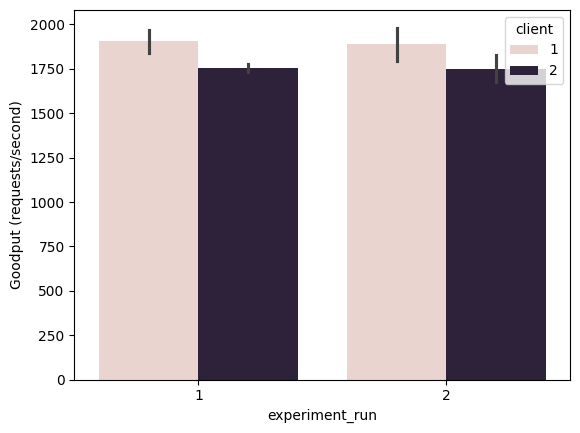

In [30]:
import seaborn as sns

sns.barplot(data=df_performance, x='experiment_run', y='Goodput (requests/second)', hue='client')
plt.show()


# Performance at Ingestion

In [31]:
df_performance = collect.get_connections()
#df_performance = collect.get_loading_time_max_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486
connection,1775852722-PostgreSQL-1-1-1024-1-1-1,1775852722-PostgreSQL-1-1-1024-1-2-1,1775852722-PostgreSQL-1-1-1024-1-2-2,1775852722-PostgreSQL-1-1-1024-2-1-1,1775852722-PostgreSQL-1-1-1024-2-2-1,1775852722-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-1-1-1,1775855486-PostgreSQL-1-1-1024-1-1-2,1775855486-PostgreSQL-1-1-1024-1-1-3,1775855486-PostgreSQL-1-1-1024-1-1-4,1775855486-PostgreSQL-1-1-1024-1-2-1,1775855486-PostgreSQL-1-1-1024-1-2-2,1775855486-PostgreSQL-1-1-1024-1-2-3,1775855486-PostgreSQL-1-1-1024-1-2-4,1775855486-PostgreSQL-1-1-1024-1-2-5,1775855486-PostgreSQL-1-1-1024-1-2-6,1775855486-PostgreSQL-1-1-1024-1-2-7,1775855486-PostgreSQL-1-1-1024-1-2-8,1775855486-PostgreSQL-1-1-1024-2-1-1,1775855486-PostgreSQL-1-1-1024-2-1-2,1775855486-PostgreSQL-1-1-1024-2-1-3,1775855486-PostgreSQL-1-1-1024-2-1-4,1775855486-PostgreSQL-1-1-1024-2-2-1,1775855486-PostgreSQL-1-1-1024-2-2-2,1775855486-PostgreSQL-1-1-1024-2-2-3,1775855486-PostgreSQL-1-1-1024-2-2-4,1775855486-PostgreSQL-1-1-1024-2-2-5,1775855486-PostgreSQL-1-1-1024-2-2-6,1775855486-PostgreSQL-1-1-1024-2-2-7,1775855486-PostgreSQL-1-1-1024-2-2-8
configuration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-2-2
experiment_run,1,1,1,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2
client,1,2,2,1,2,2,1,1,1,1,2,2,2,2,2,2,2,2,1,1,1,1,2,2,2,2,2,2,2,2
dockerimage,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18

# Hardware Monitoring for Loading Phase

In [32]:
df_performance = collect.get_monitoring_aggregated_per_phase("loading")
df_performance = collect.add_metadata(df_performance)
#df_performance_first = df_performance[df_performance['client']==1]
#df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

combine on index and column 'phase'


phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-2,1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-2,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-2,1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],6893.96,6893.96,7349.80,7349.80,6909.47,6909.47,7206.97,7206.97
Memory Usage Cached [MiB],7812.44,7812.44,8704.14,8704.14,7821.62,7821.62,8420.17,8420.17
CPU Utilization,2.20,2.20,1.65,1.65,1.78,1.78,1.63,1.63
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],743.49,743.49,6150.58,6150.58,677.26,677.26,5871.49,5871.49
CPU User Time [s],675.68,675.68,3754.07,3754.07,611.10,611.10,3565.82,3565.82
CPU System Time [s],67.81,67.81,2396.51,2396.51,66.16,66.16,2305.66,2305.66
Network Rx Total [MiB],1801.91,1801.91,5385.74,5385.74,1800.62,1800.62,5299.26,5299.26
Network Tx Total [MiB],1450.09,1450.09,4536.44,4536.44,1342.13,1342.13,4387.56,4387.56


In [33]:
#plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [34]:
#plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [35]:
#plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Efficiency

In [36]:
client = 1

df_performance_monitoring = collect.get_monitoring_aggregated_per_phase(type="stream")
#df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_aggregated_per_phase()
#df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, left_index=True, right_index=True, how='left')
#merged_df = pd.merge(df_performance, df_performance_monitoring, on=['phase'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df = merged_df[merged_df['client'] == client]
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df.T

,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-2-1
phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-2-1
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024
experiment_run,1,2,1,2
client,1,1,1,1
code,1775852722,1775852722,1775855486,1775855486
pod_count,1,1,4,4
duration,307,305,305,305
bench,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres
target,16384,16384,20480,20480


In [37]:
df = collect.add_metadata(merged_df)
df.T

combine on index and column 'phase'


phase,1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-2-1
configuration,1775852722-PostgreSQL-1-1-1024,1775852722-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024,1775855486-PostgreSQL-1-1-1024
experiment_run,1,2,1,2
client,1,1,1,1
code,1775852722,1775852722,1775855486,1775855486
pod_count,1,1,4,4
duration,307,305,305,305
bench,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres
target,16384,16384,20480,20480
time,300.00,300.00,300.00,300.00


In [38]:
df[['phase', 'code', 'configuration', 'experiment_run', 'client', 'type_tenants', 'num_tenants', 'vol_tenants']]

,phase,code,configuration,experiment_run,client,type_tenants,num_tenants,vol_tenants
phase,,,,,,,,
1775852722-PostgreSQL-1-1-1024-1-1,1775852722-PostgreSQL-1-1-1024-1-1,1775852722,1775852722-PostgreSQL-1-1-1024,1,1,,0,False
1775852722-PostgreSQL-1-1-1024-2-1,1775852722-PostgreSQL-1-1-1024-2-1,1775852722,1775852722-PostgreSQL-1-1-1024,2,1,,0,False
1775855486-PostgreSQL-1-1-1024-1-1,1775855486-PostgreSQL-1-1-1024-1-1,1775855486,1775855486-PostgreSQL-1-1-1024,1,1,,0,False
1775855486-PostgreSQL-1-1-1024-2-1,1775855486-PostgreSQL-1-1-1024-2-1,1775855486,1775855486-PostgreSQL-1-1-1024,2,1,,0,False
